In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model
print("test")

2026-03-30 06:47:42.147637: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-30 06:47:42.182303: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-30 06:47:42.182352: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-30 06:47:42.183974: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-30 06:47:42.190684: I tensorflow/core/platform/cpu_feature_guar

test


In [58]:
from pathlib import Path
import os
p = Path("/workspace/samples/EnhancedBias_run00500306_gFEX_digitzedMET.parquet")

print("exists:", p.exists())
print("is_file:", p.is_file())
print("is_symlink:", p.is_symlink())
print("lexists:", os.path.lexists(p))
print("realpath:", os.path.realpath(p))

exists: True
is_file: True
is_symlink: True
lexists: True
realpath: /eos/home-i03/m/mlarson/AGHOST_gFEX/EnhancedBias_run00500306_gFEX_digitzedMET.parquet


In [109]:

file_path = "/workspace/samples/EnhancedBias_run00500306_gFEX_digitzedMET.parquet"

df = pd.read_parquet(file_path)

In [110]:
df.head(20)

,mhxDigi,mhyDigi,msxDigi,msyDigi,metxDigi,metyDigi,metDigi,sumEtDigi,eventWeight,eventBiasedFlag
0,0,0,33,41,18,-9,20,0,12.000,False
1,0,0,15,7,14,9,16,0,5.000,False
2,0,0,35,-144,24,-28,36,0,453438.000,True
3,0,0,162,-255,57,-93,109,0,13740.600,False
4,0,0,56,2,-7,13,14,0,453438.000,True
5,0,0,-54,1,-19,-2,19,0,5.000,False
6,0,0,19,-3,0,-14,14,0,5.000,False
7,0,0,-67,36,-23,11,25,0,493448.000,True
8,-74,-2,114,-137,-46,-52,69,72,54962.200,False
9,0,0,143,-204,37,-58,68,0,453438.000,True


In [111]:
df = df.drop(columns=["eventWeight", "eventBiasedFlag"])
train_df, test_df = train_test_split(
    df,
    test_size=0.2,   # 20% test
    random_state=42  # reproducibility
)
display(train_df)
display(test_df)

,mhxDigi,mhyDigi,msxDigi,msyDigi,metxDigi,metyDigi,metDigi,sumEtDigi
35149,0,0,-10,69,-2,47,47,0
555499,0,0,-61,-42,-20,-15,25,0
80047,0,0,-27,-136,-15,-58,59,0
102935,0,0,-104,-19,-38,-1,38,0
48978,0,0,0,-46,15,-27,30,0
...,...,...,...,...,...,...,...,...
259178,-86,41,1,11,-72,34,79,644
365838,0,0,-12,18,-1,19,19,0
131932,0,0,-50,86,-25,62,66,0
671155,77,67,-184,6,12,58,59,842


,mhxDigi,mhyDigi,msxDigi,msyDigi,metxDigi,metyDigi,metDigi,sumEtDigi
737009,0,0,12,-36,-15,-21,25,0
585498,0,0,65,-341,59,-108,123,0
980505,123,26,-133,-75,50,32,59,121
793335,0,0,69,2,41,5,41,0
335081,0,0,23,86,7,17,18,0
...,...,...,...,...,...,...,...,...
958833,102,4,-31,130,67,55,86,512
474433,0,0,-84,14,-32,-5,32,0
679623,0,0,-27,126,-16,25,29,0
267957,390,250,-100,-157,350,190,398,705


In [112]:
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [113]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df)
X_test = scaler.transform(test_df)

input_dim = X_train.shape[1]
latent_dim = 3   # tune this later


In [114]:
# ----------------------------
# 2. Build the autoencoder
# ----------------------------
inputs = keras.Input(shape=(input_dim,))

# Encoder
x = layers.Dense(32, activation="relu")(inputs)
x = layers.Dense(16, activation="relu")(x)
latent = layers.Dense(latent_dim, activation="linear", name="latent")(x)

# Decoder
x = layers.Dense(16, activation="relu")(latent)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(input_dim, activation="linear")(x)

autoencoder = keras.Model(inputs, outputs, name="autoencoder")

# Optional separate encoder model
encoder = keras.Model(inputs, latent, name="encoder")

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

autoencoder.summary()

Model: "autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_11 (InputLayer)       [(None, 8)]               0         
                                                                 
 dense_39 (Dense)            (None, 32)                288       
                                                                 
 dense_40 (Dense)            (None, 16)                528       
                                                                 
 latent (Dense)              (None, 3)                 51        
                                                                 
 dense_41 (Dense)            (None, 16)                64        
                                                                 
 dense_42 (Dense)            (None, 32)                544       
                                                                 
 dense_43 (Dense)            (None, 8)                 

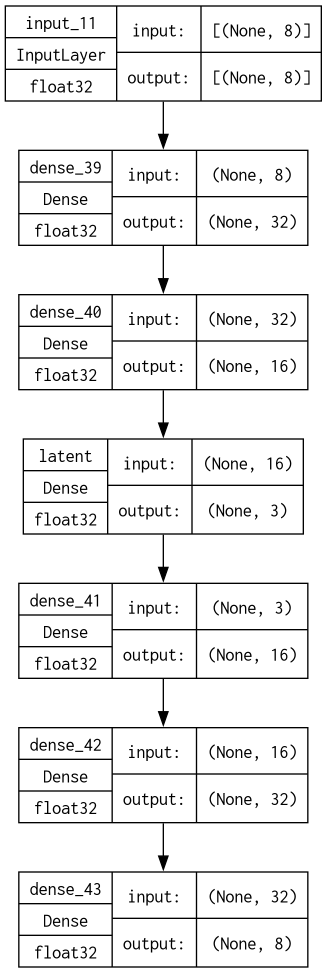

In [116]:
from tensorflow.keras.utils import plot_model

plot_model(
    autoencoder,
    to_file="basic_autoencoder.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    expand_nested=True
)

In [117]:
# ----------------------------
# 3. Train
# ----------------------------
history = autoencoder.fit(
    X_train,
    X_train,   # target is the input itself
    validation_data=(X_test, X_test),
    epochs=15,
    batch_size=256,
    shuffle=True,
    verbose=1
)

Epoch 1/15
3216/3216 [==============================] - 13s 4ms/step - loss: 0.1467 - val_loss: 0.1041
Epoch 2/15
3216/3216 [==============================] - 12s 4ms/step - loss: 0.0965 - val_loss: 0.0916
Epoch 3/15
3216/3216 [==============================] - 12s 4ms/step - loss: 0.0871 - val_loss: 0.0840
Epoch 4/15
3216/3216 [==============================] - 12s 4ms/step - loss: 0.0810 - val_loss: 0.0793
Epoch 5/15
3216/3216 [==============================] - 12s 4ms/step - loss: 0.0768 - val_loss: 0.0754
Epoch 6/15
3216/3216 [==============================] - 12s 4ms/step - loss: 0.0743 - val_loss: 0.0740
Epoch 7/15
3216/3216 [==============================] - 12s 4ms/step - loss: 0.0725 - val_loss: 0.0727
Epoch 8/15
3216/3216 [==============================] - 12s 4ms/step - loss: 0.0711 - val_loss: 0.0701
Epoch 9/15
3216/3216 [==============================] - 12s 4ms/step - loss: 0.0697 - val_loss: 0.0706
Epoch 10/15
3216/3216 [==============================] - 12s 4ms/step - l

In [118]:
# ----------------------------
# 4. Reconstruction errors
# ----------------------------
X_train_pred = autoencoder.predict(X_train, verbose=0)
X_test_pred = autoencoder.predict(X_test, verbose=0)

train_mse = np.mean((X_train - X_train_pred) ** 2, axis=1)
test_mse = np.mean((X_test - X_test_pred) ** 2, axis=1)

# Example threshold: 99th percentile of train reconstruction error
threshold = np.percentile(train_mse, 99)

print("Threshold:", threshold)

# Flag anomalies in test set
test_anomalies = test_mse > threshold
print("Number of anomalous test events:", np.sum(test_anomalies))


Threshold: 0.703447958001558
Number of anomalous test events: 2077


In [119]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------------
# Recover unscaled test features
# -----------------------------------
X_test_unscaled = scaler.inverse_transform(X_test)

# Put test set into a DataFrame for easy plotting
test_df = pd.DataFrame(X_test_unscaled, columns=df.columns)

# Add anomaly information
test_df["anomaly_score"] = test_mse
test_df["is_anomaly"] = test_anomalies

print("Fraction anomalous:", test_df["is_anomaly"].mean())

Fraction anomalous: 0.010091538072841761


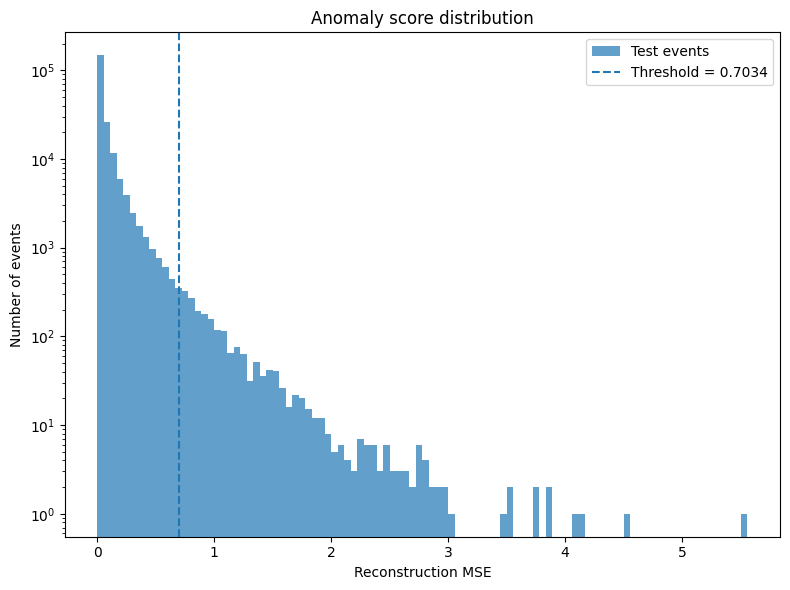

In [120]:
plt.figure(figsize=(8, 6))
plt.hist(test_df["anomaly_score"], bins=100, alpha=0.7, label="Test events")
plt.axvline(threshold, linestyle="--", label=f"Threshold = {threshold:.4f}")
plt.yscale("log")
plt.xlabel("Reconstruction MSE")
plt.ylabel("Number of events")
plt.title("Anomaly score distribution")
plt.legend()
plt.tight_layout()
plt.show()

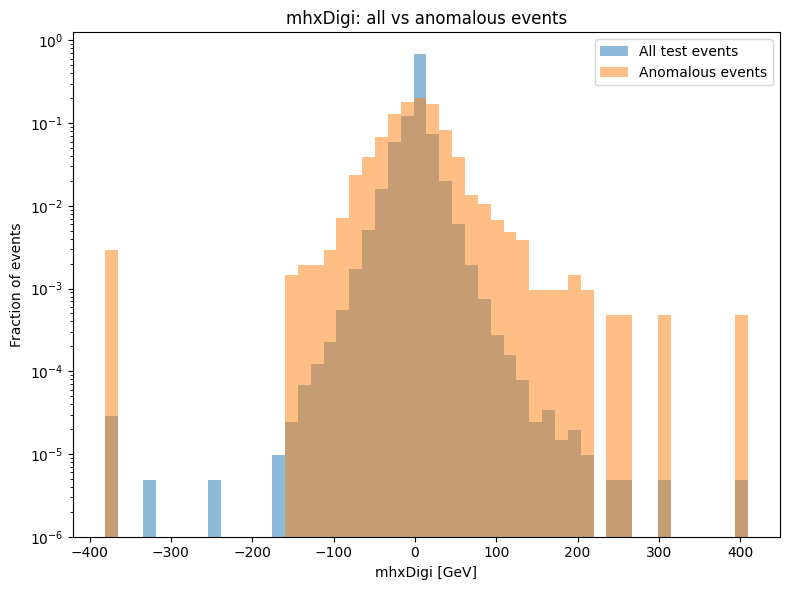

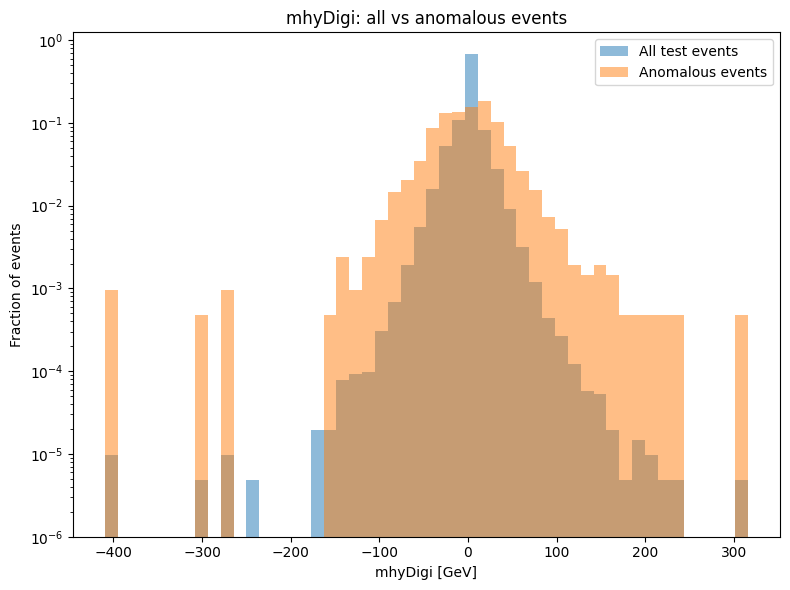

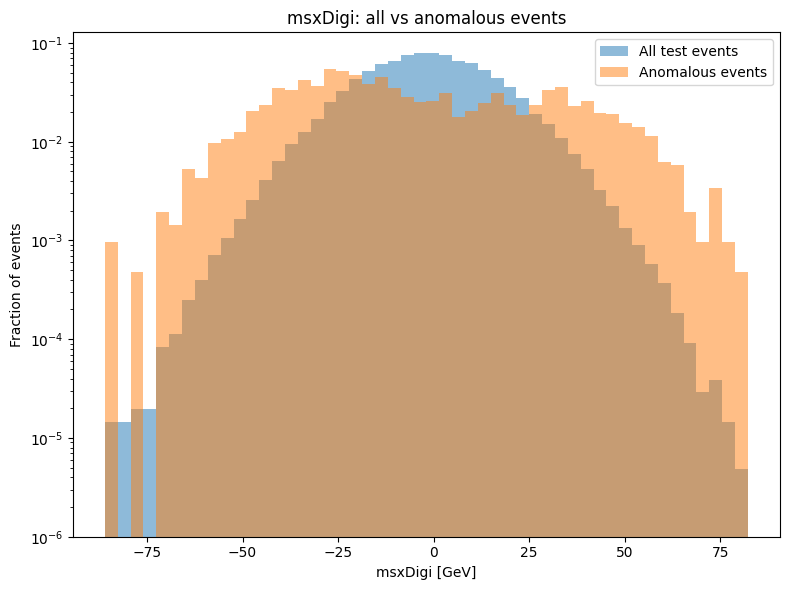

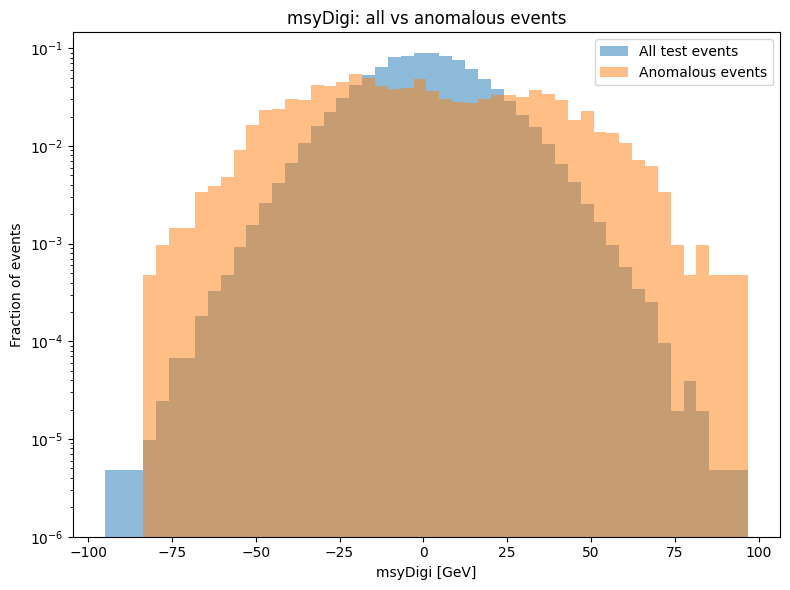

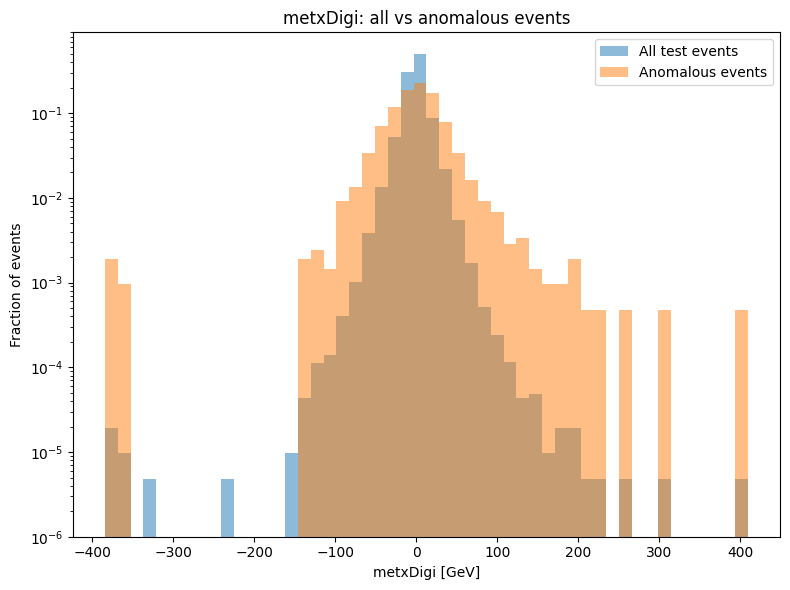

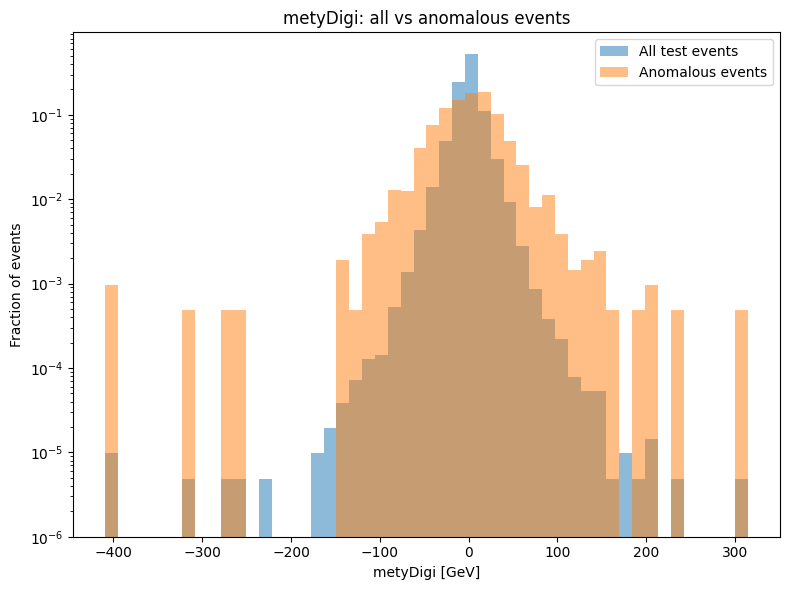

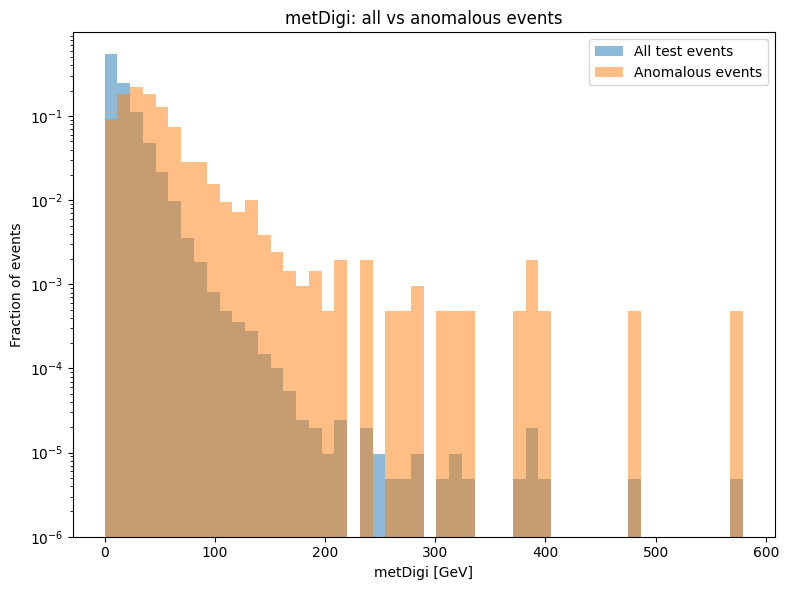

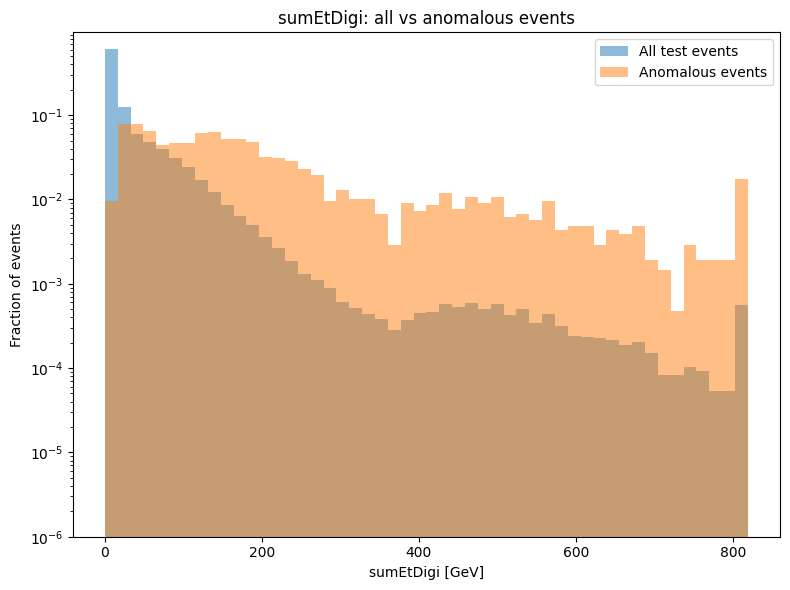

In [121]:
import numpy as np
import matplotlib.pyplot as plt

variables_to_plot = [
    "mhxDigi",
    "mhyDigi",
    "msxDigi",
    "msyDigi",
    "metxDigi",
    "metyDigi",
    "metDigi",
    "sumEtDigi"
]

scale = 0.2  # 200 MeV → GeV

for var in variables_to_plot:
    plt.figure(figsize=(8, 6))

    # convert to GeV
    data_all = test_df[var] * scale
    data_anom = test_df.loc[test_df["is_anomaly"], var] * scale

    # counts
    n_all = len(data_all)
    n_anom = len(data_anom)

    weights_all = np.ones(n_all) / n_all
    weights_anom = np.ones(n_anom) / n_anom if n_anom > 0 else None

    # consistent binning
    bins = np.histogram_bin_edges(data_all, bins=50)

    plt.hist(
        data_all,
        bins=bins,
        weights=weights_all,
        alpha=0.5,
        label="All test events"
    )

    if n_anom > 0:
        plt.hist(
            data_anom,
            bins=bins,
            weights=weights_anom,
            alpha=0.5,
            label="Anomalous events"
        )

    # axis labels (physics-friendly)
    plt.xlabel(f"{var} [GeV]")
    plt.ylabel("Fraction of events")
    plt.title(f"{var}: all vs anomalous events")

    plt.yscale("log")
    plt.ylim(bottom=1e-6)

    plt.legend()
    plt.tight_layout()
    plt.show()

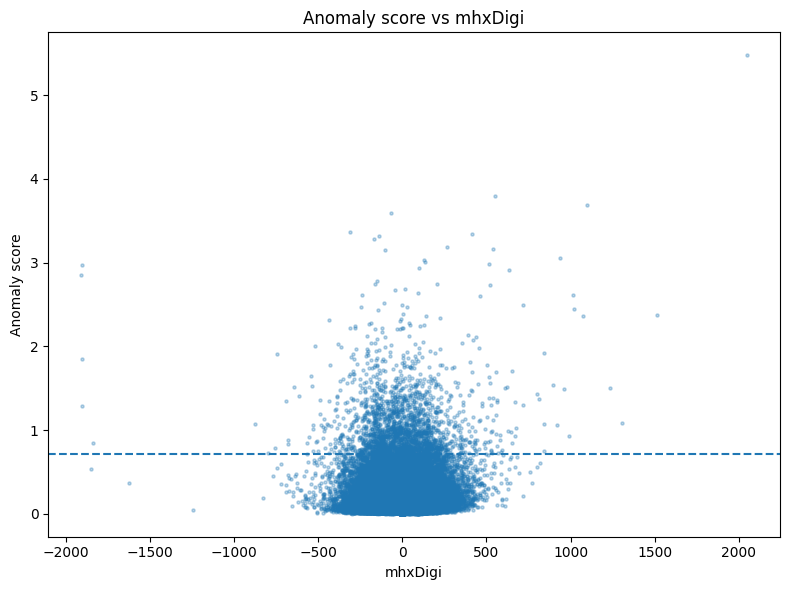

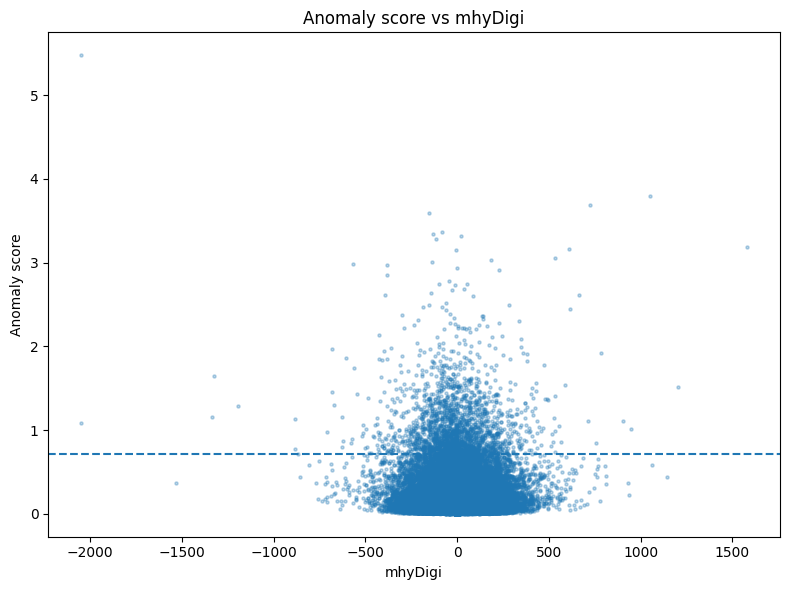

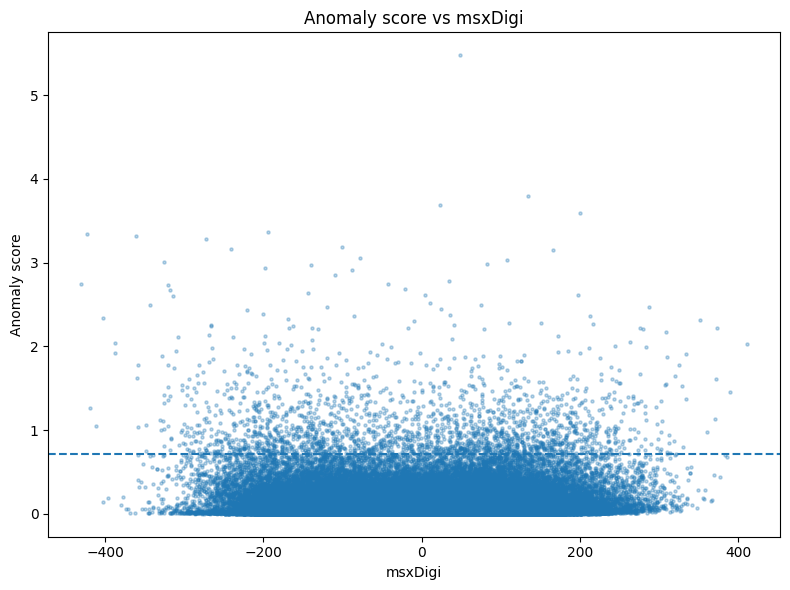

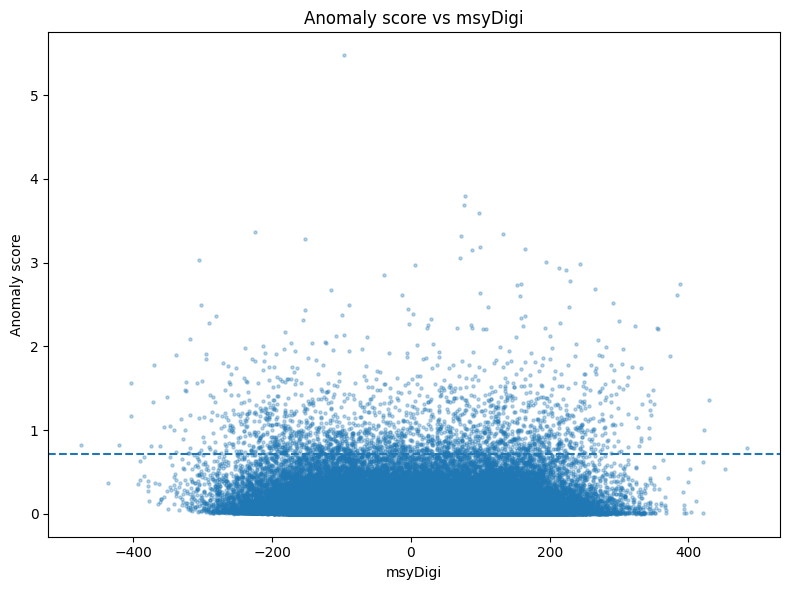

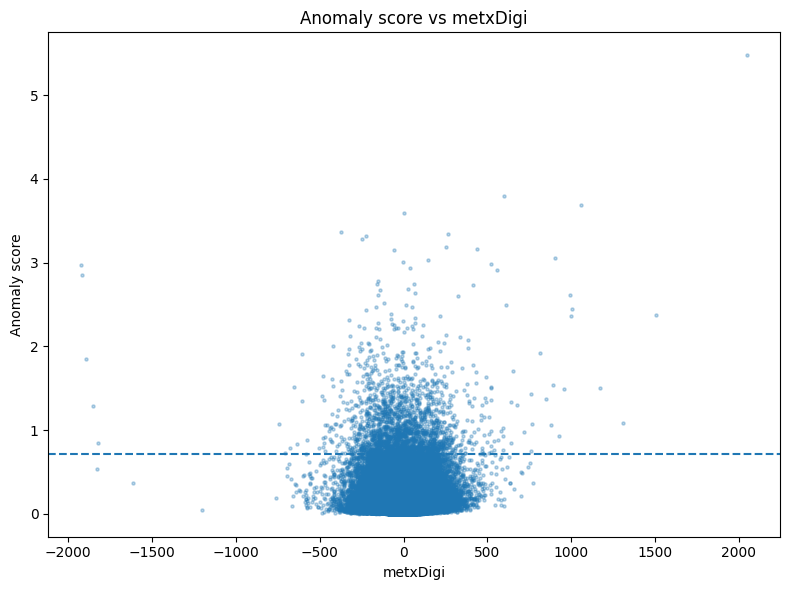

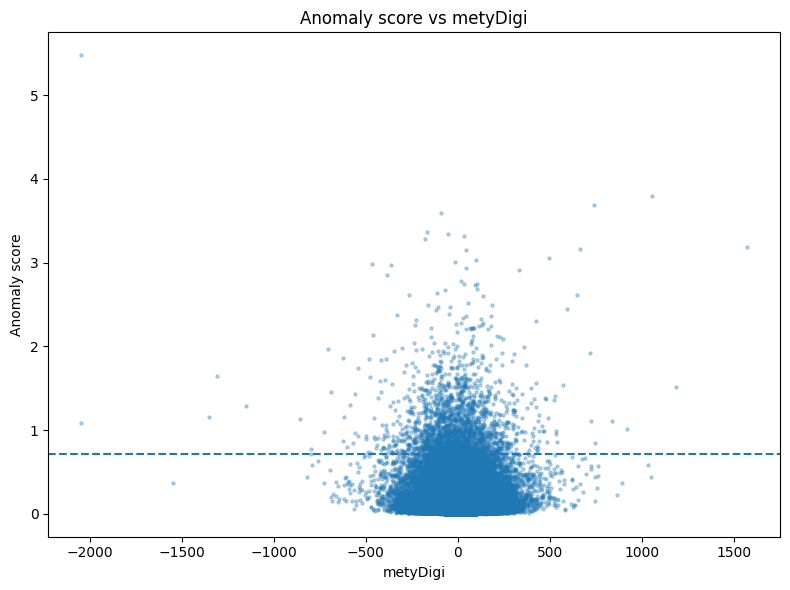

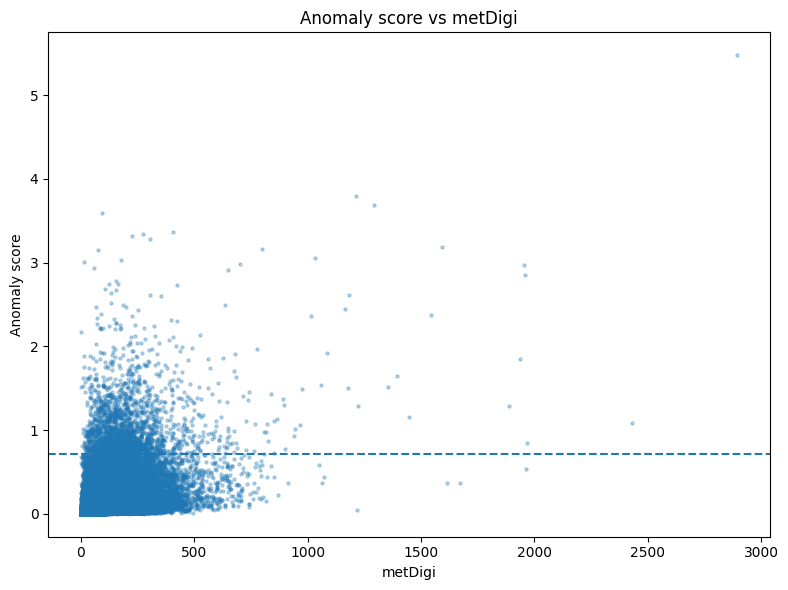

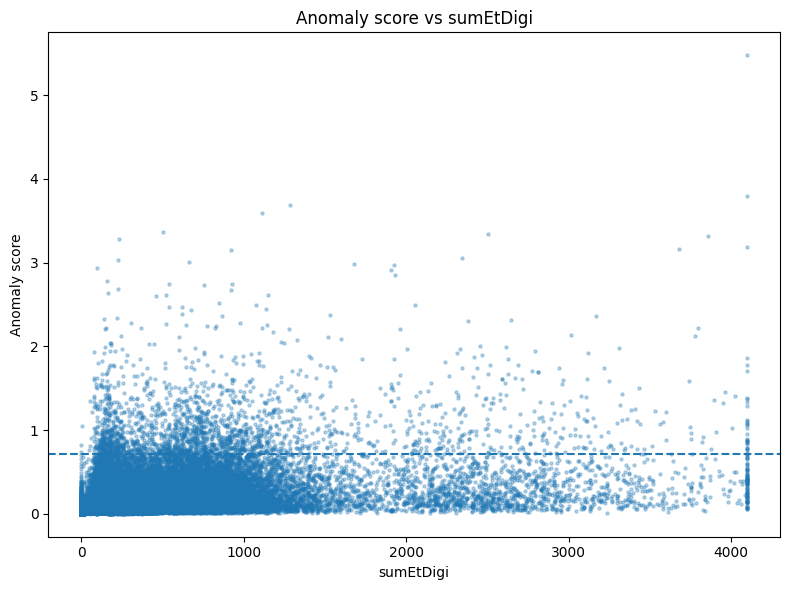

In [79]:
for var in variables_to_plot:
    plt.figure(figsize=(8, 6))
    plt.scatter(test_df[var], test_df["anomaly_score"], s=5, alpha=0.3)
    plt.axhline(threshold, linestyle="--")
    plt.xlabel(var)
    plt.ylabel("Anomaly score")
    plt.title(f"Anomaly score vs {var}")
    plt.tight_layout()
    plt.show()

In [29]:
most_anomalous = test_df.sort_values("anomaly_score", ascending=False)
print(most_anomalous.head(20))

        mhxDigi  mhyDigi  msxDigi  msyDigi  metxDigi  metyDigi  metDigi  \
175037    294.0   -131.0   -190.0    100.0     237.0    -104.0    258.0   
80709     309.0   -215.0    -46.0     -2.0     309.0    -224.0    381.0   
10335    1305.0  -2048.0     85.0    -66.0    1308.0   -2048.0   2430.0   
74169     486.0    -84.0   -206.0     62.0     341.0     -71.0    348.0   
5860      237.0    -17.0   -152.0    -63.0     155.0     -65.0    168.0   
2455      213.0   -194.0    -96.0    -22.0     184.0    -160.0    243.0   
164981    228.0    -45.0   -213.0     71.0     145.0      -4.0    145.0   
199353    -79.0    192.0    242.0      4.0      20.0     189.0    190.0   
46520    1074.0    140.0    -86.0    165.0    1000.0     183.0   1016.0   
56198     -85.0    -48.0    -52.0    297.0    -132.0      83.0    155.0   
162823    -29.0    156.0   -145.0     99.0     -86.0     182.0    201.0   
119308    290.0    -21.0   -285.0     25.0     213.0     -28.0    214.0   
113277     40.0    187.0 

Mean per-feature reconstruction error for anomalous events:
msxDigi      3.076682
msyDigi      2.862025
metxDigi     0.781361
mhxDigi      0.596645
sumEtDigi    0.561205
metDigi      0.373090
mhyDigi      0.224981
metyDigi     0.204653
dtype: float64


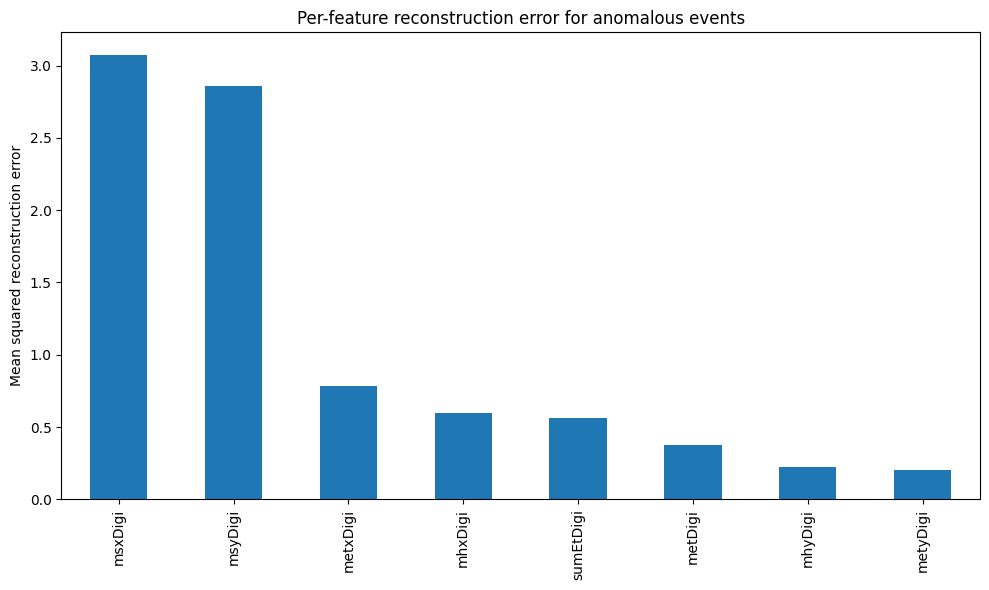

In [98]:
feature_reco_error = (X_test - X_test_pred) ** 2
feature_reco_error_unscaled = pd.DataFrame(
    feature_reco_error,
    columns=df.columns
)

mean_feature_error_anom = feature_reco_error_unscaled[test_anomalies].mean().sort_values(ascending=False)
mean_feature_error_all = feature_reco_error_unscaled.mean().sort_values(ascending=False)

print("Mean per-feature reconstruction error for anomalous events:")
print(mean_feature_error_anom)

plt.figure(figsize=(10, 6))
mean_feature_error_anom.plot(kind="bar")
plt.ylabel("Mean squared reconstruction error")
plt.title("Per-feature reconstruction error for anomalous events")
plt.tight_layout()
plt.show()

In [99]:
# copy original
df_norm = df.copy()

df_norm.head(20)

,mhxDigi,mhyDigi,msxDigi,msyDigi,metxDigi,metyDigi,metDigi,sumEtDigi
0,0,0,33,41,18,-9,20,0
1,0,0,15,7,14,9,16,0
2,0,0,35,-144,24,-28,36,0
3,0,0,162,-255,57,-93,109,0
4,0,0,56,2,-7,13,14,0
5,0,0,-54,1,-19,-2,19,0
6,0,0,19,-3,0,-14,14,0
7,0,0,-67,36,-23,11,25,0
8,-74,-2,114,-137,-46,-52,69,72
9,0,0,143,-204,37,-58,68,0


In [101]:
df_features = df_norm

df_features.head(20)

,mhxDigi,mhyDigi,msxDigi,msyDigi,metxDigi,metyDigi,metDigi,sumEtDigi
0,0,0,33,41,18,-9,20,0
1,0,0,15,7,14,9,16,0
2,0,0,35,-144,24,-28,36,0
3,0,0,162,-255,57,-93,109,0
4,0,0,56,2,-7,13,14,0
5,0,0,-54,1,-19,-2,19,0
6,0,0,19,-3,0,-14,14,0
7,0,0,-67,36,-23,11,25,0
8,-74,-2,114,-137,-46,-52,69,72
9,0,0,143,-204,37,-58,68,0


In [102]:
# previous and next rows
df_prev = df_features.shift(1)
df_next = df_features.shift(-1)

# rename columns to keep them distinct
df_prev.columns = [f"{c}_prev" for c in df_prev.columns]
df_next.columns = [f"{c}_next" for c in df_next.columns]

# combine
df_context = pd.concat([df_prev, df_features, df_next], axis=1)

# drop first and last rows (invalid due to shift)
df_context = df_context.iloc[1:-1].reset_index(drop=True)

df_context.head(20)

,mhxDigi_prev,mhyDigi_prev,msxDigi_prev,msyDigi_prev,metxDigi_prev,metyDigi_prev,metDigi_prev,sumEtDigi_prev,mhxDigi,mhyDigi,...,metDigi,sumEtDigi,mhxDigi_next,mhyDigi_next,msxDigi_next,msyDigi_next,metxDigi_next,metyDigi_next,metDigi_next,sumEtDigi_next
0,0.0,0.0,33.0,41.0,18.0,-9.0,20.0,0.0,0,0,...,16,0,0.0,0.0,35.0,-144.0,24.0,-28.0,36.0,0.0
1,0.0,0.0,15.0,7.0,14.0,9.0,16.0,0.0,0,0,...,36,0,0.0,0.0,162.0,-255.0,57.0,-93.0,109.0,0.0
2,0.0,0.0,35.0,-144.0,24.0,-28.0,36.0,0.0,0,0,...,109,0,0.0,0.0,56.0,2.0,-7.0,13.0,14.0,0.0
3,0.0,0.0,162.0,-255.0,57.0,-93.0,109.0,0.0,0,0,...,14,0,0.0,0.0,-54.0,1.0,-19.0,-2.0,19.0,0.0
4,0.0,0.0,56.0,2.0,-7.0,13.0,14.0,0.0,0,0,...,19,0,0.0,0.0,19.0,-3.0,0.0,-14.0,14.0,0.0
5,0.0,0.0,-54.0,1.0,-19.0,-2.0,19.0,0.0,0,0,...,14,0,0.0,0.0,-67.0,36.0,-23.0,11.0,25.0,0.0
6,0.0,0.0,19.0,-3.0,0.0,-14.0,14.0,0.0,0,0,...,25,0,-74.0,-2.0,114.0,-137.0,-46.0,-52.0,69.0,72.0
7,0.0,0.0,-67.0,36.0,-23.0,11.0,25.0,0.0,-74,-2,...,69,72,0.0,0.0,143.0,-204.0,37.0,-58.0,68.0,0.0
8,-74.0,-2.0,114.0,-137.0,-46.0,-52.0,69.0,72.0,0,0,...,68,0,0.0,0.0,10.0,57.0,7.0,37.0,37.0,0.0
9,0.0,0.0,143.0,-204.0,37.0,-58.0,68.0,0.0,0,0,...,37,0,0.0,0.0,65.0,181.0,16.0,44.0,46.0,0.0


In [103]:
base_features = [
    "mhxDigi", "mhyDigi", "msxDigi", "msyDigi",
    "metxDigi", "metyDigi", "metDigi", "sumEtDigi"
]

ordered_cols = (
    [f"{f}_prev" for f in base_features] +
    base_features +
    [f"{f}_next" for f in base_features]
)

X = df_context[ordered_cols].to_numpy(dtype="float32")
X = X.reshape(-1, 3, 8)

print(X.shape)  # should be (n_samples, 3, 8)

(1029076, 3, 8)


In [104]:
train_df, test_df = train_test_split(
    X,
    test_size=0.2,   # 20% test
    random_state=43  # reproducibility
)
display(train_df)
display(test_df)

array([[[   0.,    0.,   -1., ...,   29.,   29.,    0.],
        [   0.,    0.,   35., ...,   13.,   15.,    0.],
        [   5.,   -6.,   -2., ...,   37.,   37.,    0.]],

       [[   0.,    0.,  -99., ...,   -4.,   48.,    0.],
        [   0.,    0.,  -84., ...,  -28.,   28.,    0.],
        [  -4., -101.,   12., ...,  -69.,   69.,   98.]],

       [[  42.,   19.,   31., ...,   20.,   55.,  220.],
        [  32.,  -78., -153., ...,  -69.,   74.,  474.],
        [ -73.,  -56.,   54., ...,  -21.,   75.,  208.]],

       ...,

       [[   0.,    0., -130., ...,    8.,   46.,    0.],
        [   0.,    0.,   -4., ...,   22.,   38.,    0.],
        [   0.,   81.,  -70., ...,   74.,   76.,   79.]],

       [[   0.,    0., -203., ...,   11.,   67.,    0.],
        [   0.,    0.,  -75., ...,  -29.,   40.,    0.],
        [   0.,    0.,   18., ...,   30.,   35.,    0.]],

       [[   0.,    0.,   70., ...,  -30.,   34.,    0.],
        [   0.,    0.,  -16., ...,   24.,   28.,    0.],
        

array([[[   0.,    0.,   36., ...,   19.,   20.,    0.],
        [   0.,    0.,  -75., ...,   -8.,   20.,    0.],
        [   0.,    0.,  -41., ...,   -7.,   15.,    0.]],

       [[ -83.,  -82.,   -3., ...,  -67.,  126.,  113.],
        [  92.,   99.,   21., ...,   94.,  119.,  485.],
        [   0.,    0.,  -19., ...,  -14.,   17.,    0.]],

       [[ -41., -175.,  115., ..., -166.,  167., 1301.],
        [  70.,  -76., -102., ...,  -63.,   87.,  280.],
        [   0.,    0.,  111., ...,  -41.,   81.,    0.]],

       ...,

       [[  30.,   35.,  151., ...,   36.,   93.,  576.],
        [  14.,  -23.,  -42., ...,  -84.,   84.,   26.],
        [-135.,  133.,  -12., ...,   95.,  150.,  832.]],

       [[   0.,    0.,   53., ...,  -58.,   59.,    0.],
        [ -97.,  -90.,   94., ...,  -42.,   76.,  129.],
        [   0.,    0.,   78., ...,   27.,   27.,    0.]],

       [[  -9.,  -33.,  -72., ..., -108.,  108.,   51.],
        [   0.,    0.,   71., ...,   40.,   44.,    0.],
        

In [105]:
from sklearn.preprocessing import StandardScaler

# train_df and test_df are assumed to already be numpy arrays of shape (n_samples, 3, 8)

scaler = StandardScaler()

n_train = train_df.shape[0]
n_test = test_df.shape[0]

# collapse samples and BX axes together: (n_samples*3, 8)
train_2d = train_df.reshape(-1, train_df.shape[-1])
test_2d  = test_df.reshape(-1, test_df.shape[-1])

# fit only on training data
train_2d_scaled = scaler.fit_transform(train_2d)
test_2d_scaled  = scaler.transform(test_2d)

# reshape back to (n_samples, 3, 8)
X_train = train_2d_scaled.reshape(n_train, 3, 8)
X_test  = test_2d_scaled.reshape(n_test, 3, 8)

print(X_train.shape)
print(X_test.shape)

(823260, 3, 8)
(205816, 3, 8)


In [106]:
from tensorflow import keras
from tensorflow.keras import layers

n_bx = 3
n_feat_per_bx = 8
latent_dim = 16

inputs = keras.Input(shape=(n_bx, n_feat_per_bx))

# Encoder
x = layers.Conv1D(64, kernel_size=2, padding="same", activation="relu")(inputs)
x = layers.BatchNormalization()(x)

x = layers.Conv1D(128, kernel_size=2, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)

x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)
latent = layers.Dense(latent_dim, activation="linear", name="latent")(x)

# Decoder
x = layers.Dense(n_bx * 128, activation="relu")(latent)
x = layers.Reshape((n_bx, 128))(x)

x = layers.Conv1D(64, kernel_size=2, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)

outputs = layers.Conv1D(n_feat_per_bx, kernel_size=2, padding="same", activation="linear")(x)

autoencoder = keras.Model(inputs, outputs, name="conv_autoencoder")
encoder = keras.Model(inputs, latent, name="encoder")

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

autoencoder.summary()

Model: "conv_autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 3, 8)]            0         
                                                                 
 conv1d_16 (Conv1D)          (None, 3, 64)             1088      
                                                                 
 batch_normalization_20 (Ba  (None, 3, 64)             256       
 tchNormalization)                                               
                                                                 
 conv1d_17 (Conv1D)          (None, 3, 128)            16512     
                                                                 
 batch_normalization_21 (Ba  (None, 3, 128)            512       
 tchNormalization)                                               
                                                                 
 flatten_4 (Flatten)         (None, 384)          

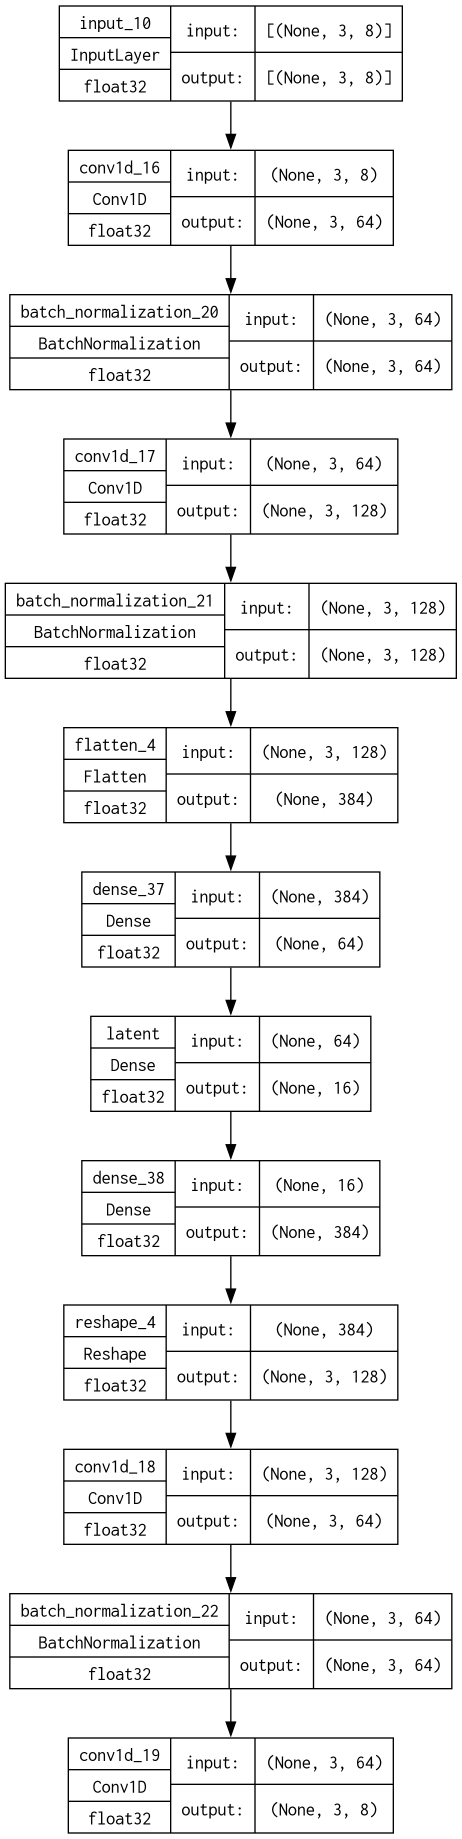

In [107]:
from tensorflow.keras.utils import plot_model

plot_model(
    autoencoder,
    to_file="autoencoder.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    expand_nested=True
)

In [49]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Visible GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.15.1
Built with CUDA: True
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [50]:
# ----------------------------
# 3. Train
# ----------------------------
history = autoencoder.fit(
    X_train,
    X_train,   # target is the input itself
    validation_data=(X_test, X_test),
    epochs=25,
    batch_size=256,
    shuffle=True,
    verbose=1
)

Epoch 1/25
3216/3216 [==============================] - 24s 7ms/step - loss: 0.0496 - val_loss: 0.0169
Epoch 2/25
3216/3216 [==============================] - 22s 7ms/step - loss: 0.0173 - val_loss: 0.0127
Epoch 3/25
3216/3216 [==============================] - 23s 7ms/step - loss: 0.0133 - val_loss: 0.0093
Epoch 4/25
3216/3216 [==============================] - 22s 7ms/step - loss: 0.0107 - val_loss: 0.0062
Epoch 5/25
3216/3216 [==============================] - 22s 7ms/step - loss: 0.0094 - val_loss: 0.0058
Epoch 6/25
3216/3216 [==============================] - 22s 7ms/step - loss: 0.0085 - val_loss: 0.0070
Epoch 7/25
3216/3216 [==============================] - 23s 7ms/step - loss: 0.0077 - val_loss: 0.0054
Epoch 8/25
3216/3216 [==============================] - 22s 7ms/step - loss: 0.0073 - val_loss: 0.0043
Epoch 9/25
3216/3216 [==============================] - 22s 7ms/step - loss: 0.0069 - val_loss: 0.0043
Epoch 10/25
3216/3216 [==============================] - 23s 7ms/step - l

KeyboardInterrupt: 